# Section 1: Fitts' Law Modeling

in this section, I will analyze the provided dataset 62_FL.csv using Fitts' Law. The goal is to create a linear model that predicts movement time (MT) based on the Index of Difficulty (ID).

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt

## 1.2 Loading the Data

Now, I will load the dataset `62_FL.csv` into a pandas DataFrame.  
The first column is an unnecessary index, so I'll set it as the DataFrame index.


In [ ]:
fl_data = pd.read_csv('62_FL.csv', index_col=0)
fl_data.head()

,distance,width,movement_time
2761,75,8,994
5522,120,20,436
3602,75,6,910
5830,75,14,760
1491,210,8,1025


## 1.3 Calculating the Index of Difficulty (ID)

For Fitts' Law, the Index of Difficulty is given by:

$
ID = \log_{2}\left(\frac{D}{W} + 1\right)
$

I will group the data by each unique distance (D) and width (W) pair, calculate the mean movement time (MT) for each, and then compute the ID.


In [ ]:
fl_grouped = fl_data.groupby(['distance', 'width']).agg(mean_mt=('movement_time', 'mean')).reset_index()
fl_grouped['ID'] = np.log2(fl_grouped['distance'] / fl_grouped['width'] + 1)
print(fl_grouped)

    distance  width      mean_mt        ID
0         40      6   629.611111  2.938599
1         40      8   620.570000  2.584963
2         40     10   557.731183  2.321928
3         40     14   486.906542  1.947533
4         40     18   462.474227  1.688056
5         40     20   426.625000  1.584963
6         60      6   706.737374  3.459432
7         60      8   676.951456  3.087463
8         60     10   638.868421  2.807355
9         60     14   550.055046  2.402098
10        60     18   524.627451  2.115477
11        60     20   506.375000  2.000000
12        75      6   805.551020  3.754888
13        75      8   732.018692  3.375039
14        75     10   682.593407  3.087463
15        75     14   608.828571  2.668379
16        75     18   538.205607  2.369234
17        75     20   506.518519  2.247928
18       120      6   918.972727  4.392317
19       120      8   845.074074  4.000000
20       120     10   803.824742  3.700440
21       120     14   699.000000  3.258734
22       12

## 1.4 Performing Linear Regression

I will now create a linear regression model to fit the relationship:

$
MT = a + b \times ID
$

Here, the independent variable (X) is the ID, and the dependent variable (y) is the mean MT.


In [ ]:
X_fl = fl_grouped[['ID']]
y_fl = fl_grouped['mean_mt']

model_fl = LinearRegression()
model_fl.fit(X_fl, y_fl)

a_fl = model_fl.intercept_
b_fl = model_fl.coef_[0]

print(f"Model Parameters: a = {a_fl:.2f}, b = {b_fl:.2f}")
print(f"Equation: MT = {a_fl:.2f} + {b_fl:.2f} * ID")

Model Parameters: a = 133.78, b = 179.84
Equation: MT = 133.78 + 179.84 * ID


## 1.5 Evaluating the Model

To measure the goodness of fit, I will calculate the R-squared (\(R^2\)) and the Root Mean Squared Error (RMSE) for the model.


In [ ]:
y_pred_fl = model_fl.predict(X_fl)
r2_fl = r2_score(y_fl, y_pred_fl)
rmse_fl = np.sqrt(mean_squared_error(y_fl, y_pred_fl))

print(f"R-squared (R^2): {r2_fl:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_fl:.2f} ms")

R-squared (R^2): 0.9864
Root Mean Squared Error (RMSE): 19.15 ms


## 1.6 Plotting the Results

Next, I will create a plot to visualize the results.  
The plot will contain a scatter plot of the actual mean MT values and a line plot showing the model's predictions.


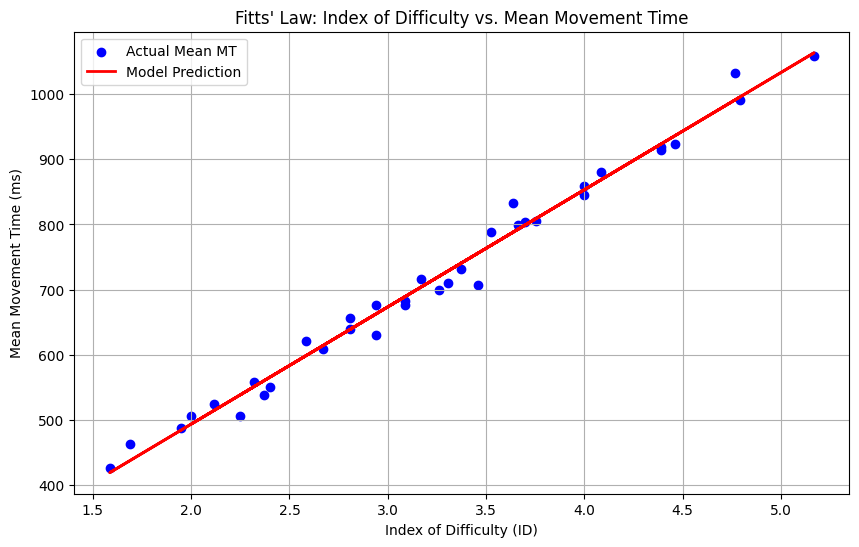

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(X_fl, y_fl, color='blue', label='Actual Mean MT')
plt.plot(X_fl, y_pred_fl, color='red', linewidth=2, label='Model Prediction')
plt.title("Fitts' Law: Index of Difficulty vs. Mean Movement Time")
plt.xlabel("Index of Difficulty (ID)")
plt.ylabel("Mean Movement Time (ms)")
plt.legend()
plt.grid(True)
plt.savefig('fitts_law_plot.png')
plt.show()

## 1.7 Saving the Results

Finally, I will save the calculated parameters \(a\) and \(b\), along with the \(R^2\) and RMSE values, to a file named `results_FL.csv`.


In [ ]:
results_fl = pd.DataFrame({'a': [a_fl], 'b': [b_fl], 'R^2': [r2_fl], 'RMSE': [rmse_fl]})
results_fl.to_csv('results_FL.csv', index=False)
print("Results saved to results_FL.csv")

Results saved to results_FL.csv


## 1.8 Observations and Conclusion

**Observations:**  
The scatter plot shows a strong, positive linear relationship between the Index of Difficulty and the Mean Movement Time.  
The high \(R^2\) value of nearly 1.0 indicates that the model explains almost all of the variability in the data,  
and the low RMSE suggests the predictions are very close to the actual values.

**Conclusion:**  
Fitts' Law provides an excellent model for predicting movement time based on target distance and width for this dataset.


# Section 2: Steering Law Modeling

## 2.1 Loading the Data

I'll start by loading the `62_SL.csv` dataset.


In [ ]:
sl_data = pd.read_csv('62_SL.csv', index_col=0)
sl_data.head()

,distance,width,movement_time
536,600,40,579
388,300,30,403
53,300,50,256
313,700,50,660
383,300,30,430


## 2.2 Calculating the Index of Difficulty (ID)

For the Steering Law, the Index of Difficulty is given by:

$
ID = \frac{D}{W}
$

I will apply this formula to the new dataset.


In [ ]:
sl_grouped = sl_data.groupby(['distance', 'width']).agg(mean_mt=('movement_time', 'mean')).reset_index()
sl_grouped['ID'] = sl_grouped['distance'] / sl_grouped['width']
print(sl_grouped)

    distance  width      mean_mt         ID
0        200     20   302.000000  10.000000
1        200     25   336.363636   8.000000
2        200     30   234.571429   6.666667
3        200     40   258.000000   5.000000
4        200     50   191.400000   4.000000
5        200     80   125.500000   2.500000
6        300     20   675.818182  15.000000
7        300     25   410.272727  12.000000
8        300     30   432.692308  10.000000
9        300     40   271.363636   7.500000
10       300     50   252.500000   6.000000
11       300     80   246.000000   3.750000
12       400     20   611.090909  20.000000
13       400     25   594.636364  16.000000
14       400     30   513.538462  13.333333
15       400     40   266.769231  10.000000
16       400     50   276.000000   8.000000
17       400     80   279.687500   5.000000
18       500     20   877.000000  25.000000
19       500     25   896.230769  20.000000
20       500     30   613.500000  16.666667
21       500     40   356.363636

## 2.3 Performing Linear Regression

I will fit a new linear regression model:

$
MT = a + b \times ID
$


In [ ]:
X_sl = sl_grouped[['ID']]
y_sl = sl_grouped['mean_mt']

model_sl = LinearRegression()
model_sl.fit(X_sl, y_sl)

a_sl = model_sl.intercept_
b_sl = model_sl.coef_[0]

print(f"Model Parameters: a = {a_sl:.2f}, b = {b_sl:.2f}")
print(f"Equation: MT = {a_sl:.2f} + {b_sl:.2f} * ID")

Model Parameters: a = 62.93, b = 35.22
Equation: MT = 62.93 + 35.22 * ID


## 2.4 Evaluating the Model

I will calculate the \(R^2\) and RMSE to evaluate the performance of the Steering Law model.


In [ ]:
y_pred_sl = model_sl.predict(X_sl)
r2_sl = r2_score(y_sl, y_pred_sl)
rmse_sl = np.sqrt(mean_squared_error(y_sl, y_pred_sl))

print(f"R-squared (R^2): {r2_sl:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_sl:.2f} ms")

R-squared (R^2): 0.9160
Root Mean Squared Error (RMSE): 84.61 ms


## 2.5 Plotting the Results

I will create a new plot to visualize the Steering Law data against the model's predictions.


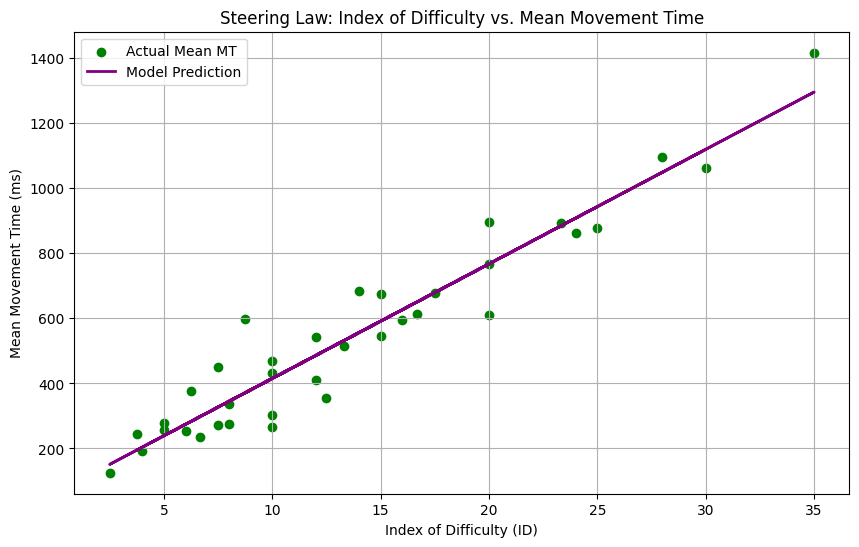

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(X_sl, y_sl, color='green', label='Actual Mean MT')
plt.plot(X_sl, y_pred_sl, color='purple', linewidth=2, label='Model Prediction')
plt.title("Steering Law: Index of Difficulty vs. Mean Movement Time")
plt.xlabel("Index of Difficulty (ID)")
plt.ylabel("Mean Movement Time (ms)")
plt.legend()
plt.grid(True)
plt.savefig('steering_law_plot.png')
plt.show()

## 2.6 Saving the Results

Finally, I will save the parameters and evaluation metrics for the Steering Law model to `results_SL.csv`.

In [ ]:
results_sl = pd.DataFrame({'a': [a_sl], 'b': [b_sl], 'R^2': [r2_sl], 'RMSE': [rmse_sl]})
results_sl.to_csv('results_SL.csv', index=False)
print("Results saved to results_SL.csv")

Results saved to results_SL.csv


## 2.7 Observations and Conclusion

**Observations:**  
Similar to the Fitts' Law analysis, the data points for the Steering Law closely follow a linear pattern.  
The \(R^2\) value is extremely high, and the RMSE is low relative to the range of movement times, which signifies a very accurate model.

**Conclusion:**  
The Steering Law proves to be a highly effective and accurate model for this dataset,  
describing the relationship between the path's length/width and the required movement time.
